In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [216]:
df = pd.read_csv("website data.csv")

In [217]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


Removing duplicate Data present in the column 

In [218]:
df.columns = df.iloc[0]

#removing dupicate data in column
df = df.drop(index= 0).reset_index(drop = True)
df.columns = ["Channel Group", "DateHour", "Users", "Session", "Engaged sessions", "Average engagement time per session","Engaged sessions per user",	"Events per session",	"Engagement rate",	"Event count"]

In [219]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Channel Group                        3182 non-null   str  
 1   DateHour                             3182 non-null   str  
 2   Users                                3182 non-null   str  
 3   Session                              3182 non-null   str  
 4   Engaged sessions                     3182 non-null   str  
 5   Average engagement time per session  3182 non-null   str  
 6   Engaged sessions per user            3182 non-null   str  
 7   Events per session                   3182 non-null   str  
 8   Engagement rate                      3182 non-null   str  
 9   Event count                          3182 non-null   str  
dtypes: str(10)
memory usage: 248.7 KB


In [233]:
df["DateHour"] = pd.to_datetime(df["DateHour"], format= "%Y%m%d%H", errors='coerce')

In [221]:
numeric_cols = df.columns.drop(["Channel Group", "DateHour"])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors ='coerce')
df['Hour'] = df["DateHour"].dt.hour

In [222]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel Group                        3182 non-null   str           
 1   DateHour                             3182 non-null   datetime64[us]
 2   Users                                3182 non-null   int64         
 3   Session                              3182 non-null   int64         
 4   Engaged sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour                   

##What Pattern or trends can you observe in website sessions and user over time ?

In [223]:
sns.set(style="whitegrid")

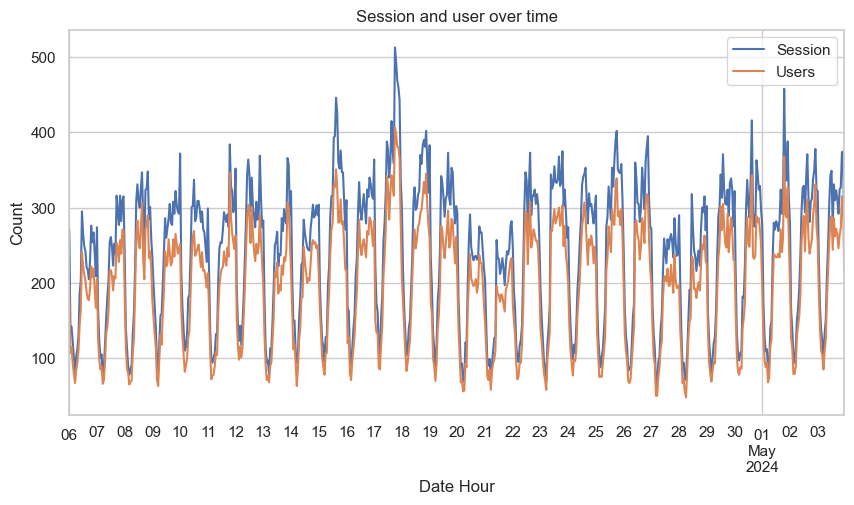

In [224]:
plt.figure(figsize=(10,5))
df.groupby("DateHour")[["Session", "Users"]].sum().plot(ax=plt.gca())
plt.title("Session and user over time")
plt.xlabel("Date Hour")
plt.ylabel("Count")
plt.show()

In [225]:
df.head()

,Channel Group,DateHour,Users,Session,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


Which marketing Channel bought the highest number of user to the website and how can we use the insight to improve out traffic from other source 

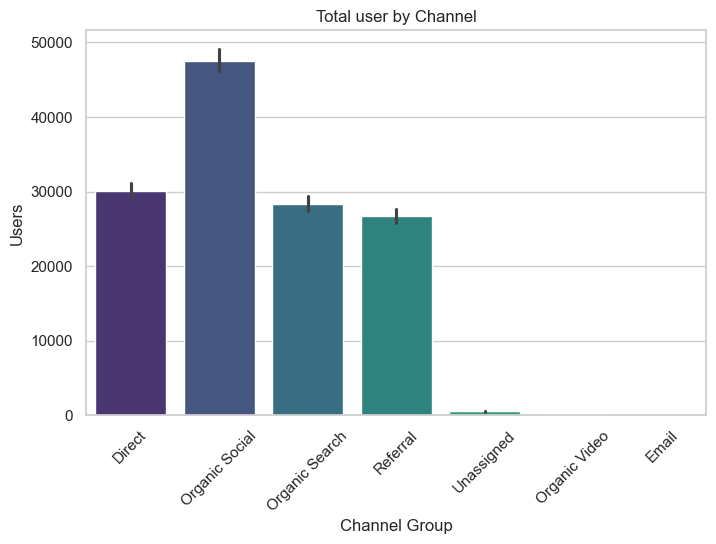

In [226]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Channel Group", y="Users",hue="Channel Group", estimator=np.sum, palette="viridis")
plt.title("Total user by Channel")
plt.xticks(rotation= 45)
plt.show()

Which channel has the highest avg engagement time, and what does tell us about user behaviour and content effectiveness  

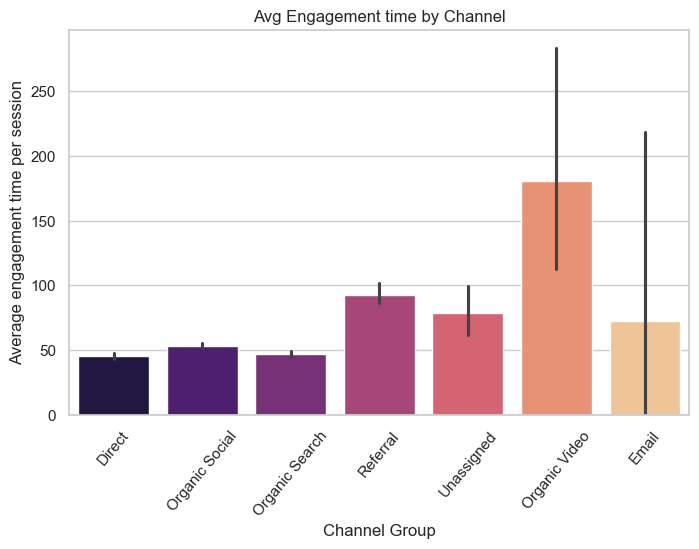

In [227]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x="Channel Group", y="Average engagement time per session", hue="Channel Group", estimator=np.mean, palette="magma")
plt.title("Avg Engagement time by Channel")
plt.xticks(rotation=50)
plt.show()

How Does engaement rate vary across different traffic channel 

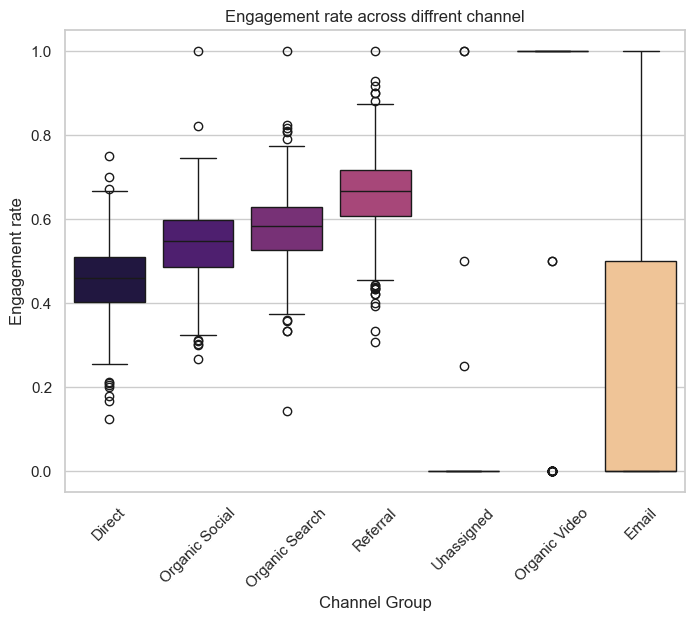

In [228]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="Channel Group", y="Engagement rate", hue="Channel Group", palette="magma")
plt.title("Engagement rate across diffrent channel")
plt.xticks(rotation=45)
plt.show()

Which Channel are driving more engaged sessions compared to non-engaged ones, and what strategies cam 
improve engagement in underperforming channels ?

Engaged VS Non-Engaged 

In [229]:
session_df = df.groupby("Channel Group")[["Session", "Engaged sessions"]].sum().reset_index()
session_df["Non-Engaged"] = session_df["Session"] - session_df["Engaged sessions"]
session_df_melted = session_df.melt(id_vars="Channel Group", value_vars=["Engaged sessions", "Non-Engaged"])

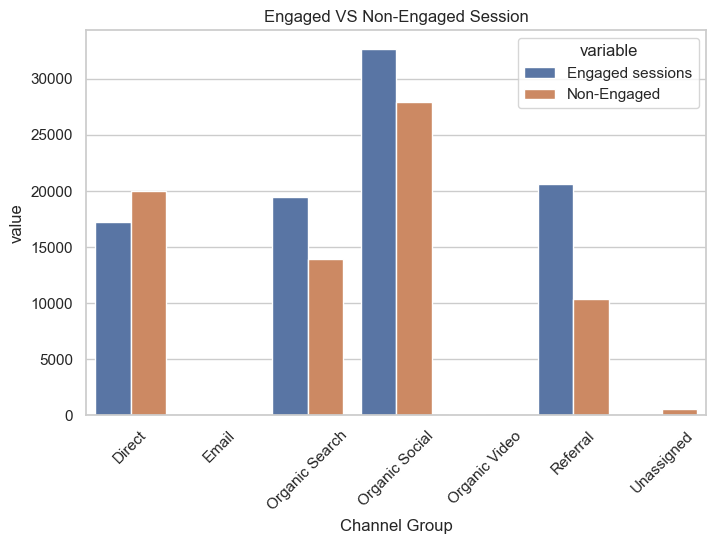

In [230]:
plt.figure(figsize=(8,5))
sns.barplot(data=session_df_melted, x="Channel Group", y="value", hue="variable")
plt.title("Engaged VS Non-Engaged Session")
plt.xticks(rotation=45)
plt.show()

At what hours of the day does each channel drive the most traffic 

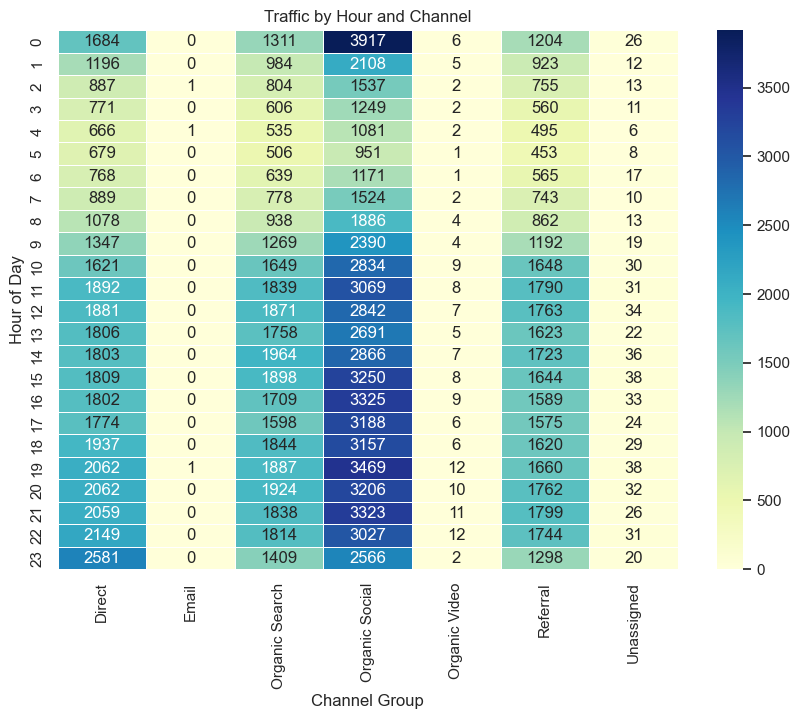

In [231]:
heatmap_data = df.groupby(["Hour", "Channel Group"])["Session"].sum().unstack().fillna(0)

plt.figure(figsize=(10,7))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=.5, annot=True, fmt= ".0f")
plt.title("Traffic by Hour and Channel")
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day")
plt.show()

Is there any corelation between high traffic Session and high engagement rate over time ?

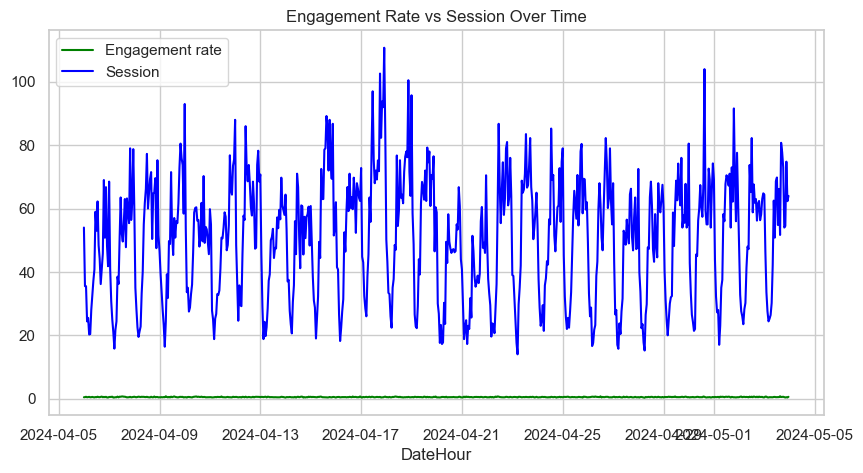

In [232]:
plt.figure(figsize=(10,5))

df_plot = df.groupby("DateHour")[["Engagement rate", "Session"]].mean().reset_index()

plt.plot(
    df_plot["DateHour"],
    df_plot["Engagement rate"],
    label="Engagement rate",
    color="green"
)

plt.plot(
    df_plot["DateHour"],
    df_plot["Session"],
    label="Session",
    color="blue"
)

plt.title("Engagement Rate vs Session Over Time")
plt.xlabel("DateHour")
plt.legend()
plt.grid(True)

plt.show()